## 0. Imports & Dataset laden

In [26]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

In [27]:
# Download latest version
path = kagglehub.dataset_download("harlfoxem/housesalesprediction")
print("Path to dataset files:", path)

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))
print(f"Dataset geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")

Path to dataset files: C:\Users\Schne\.cache\kagglehub\datasets\harlfoxem\housesalesprediction\versions\1
Dataset geladen: 21613 Zeilen, 21 Spalten


---
# Initial Data Analysis (IDA)

## What data

Der Datensatz beschreibt **Hausverkäufe in King County (Seattle, WA)** im Zeitraum Mai 2014 – Mai 2015.  
Er enthält 21.613 Transaktionen mit 21 Merkmalen.

**Kategorisierung:**
- **Identifikation:** id, date
- **Zielvariable:** price
- **Gebäudemerkmale:** bedrooms, bathrooms, sqft_living, sqft_above, sqft_basement, floors, grade, condition
- **Grundstück:** sqft_lot, waterfront, view
- **Historie:** yr_built, yr_renovated
- **Lage:** zipcode, lat, long
- **Nachbarschaft:** sqft_living15, sqft_lot15

In [28]:
# Übersicht aller Features
print(f"Datensatz: {df.shape[0]} Zeilen, {df.shape[1]} Spalten\n")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col:20s} Typ: {str(df[col].dtype):10s} Unique: {df[col].nunique()}")

Datensatz: 21613 Zeilen, 21 Spalten

   1. id                   Typ: int64      Unique: 21436
   2. date                 Typ: str        Unique: 372
   3. price                Typ: float64    Unique: 4028
   4. bedrooms             Typ: int64      Unique: 13
   5. bathrooms            Typ: float64    Unique: 30
   6. sqft_living          Typ: int64      Unique: 1038
   7. sqft_lot             Typ: int64      Unique: 9782
   8. floors               Typ: float64    Unique: 6
   9. waterfront           Typ: int64      Unique: 2
  10. view                 Typ: int64      Unique: 5
  11. condition            Typ: int64      Unique: 5
  12. grade                Typ: int64      Unique: 12
  13. sqft_above           Typ: int64      Unique: 946
  14. sqft_basement        Typ: int64      Unique: 306
  15. yr_built             Typ: int64      Unique: 116
  16. yr_renovated         Typ: int64      Unique: 70
  17. zipcode              Typ: int64      Unique: 70
  18. lat                  Typ: floa

### IDA – Datenstruktur

In [29]:
# df.shape
df.shape

(21613, 21)

In [30]:
# df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [31]:
# df.head()
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [32]:
# df.tail()
df.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,...,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [33]:
# df.nunique().sort_values()
df.nunique().sort_values()

waterfront           2
view                 5
condition            5
floors               6
grade               12
bedrooms            13
bathrooms           30
yr_renovated        70
zipcode             70
yr_built           116
sqft_basement      306
date               372
long               752
sqft_living15      777
sqft_above         946
sqft_living       1038
price             4028
lat               5034
sqft_lot15        8689
sqft_lot          9782
id               21436
dtype: int64

### **quality and quantity** data

### Quantität

In [34]:
print(f"Anzahl Datensätze:    {len(df):,}")
print(f"Anzahl Features:      {df.shape[1]}")
#
df_temp = df.copy()
df_temp['date'] = pd.to_datetime(df_temp['date'], format='%Y%m%dT%H%M%S')
print(f"Zeitraum:             {df_temp['date'].min().strftime('%Y-%m-%d')} bis {df_temp['date'].max().strftime('%Y-%m-%d')}")
print(f"Einzigartige Häuser:  {df['id'].nunique():,}")
print(f"Wiederverkäufe:       {len(df) - df['id'].nunique():,}")

Anzahl Datensätze:    21,613
Anzahl Features:      21
Zeitraum:             2014-05-02 bis 2015-05-27
Einzigartige Häuser:  21,436
Wiederverkäufe:       177


### Qualität – Missing Values

In [35]:
# df.isnull().sum().sort_values(ascending=False)
df.isnull().sum().sort_values(ascending=False)

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

### Qualität

In [36]:
# df.describe(include='all').T
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,21613.0,NaN,NaN,NaN,4580301520.864988,2876565571.312057,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0
date,21613,372,20140623T000000,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,21613.0,NaN,NaN,NaN,540088.141767,367127.196483,75000.0,321950.0,450000.0,645000.0,7700000.0
bedrooms,21613.0,NaN,NaN,NaN,3.370842,0.930062,0.0,3.0,3.0,4.0,33.0
bathrooms,21613.0,NaN,NaN,NaN,2.114757,0.770163,0.0,1.75,2.25,2.5,8.0
sqft_living,21613.0,NaN,NaN,NaN,2079.899736,918.440897,290.0,1427.0,1910.0,2550.0,13540.0
sqft_lot,21613.0,NaN,NaN,NaN,15106.967566,41420.511515,520.0,5040.0,7618.0,10688.0,1651359.0
floors,21613.0,NaN,NaN,NaN,1.494309,0.539989,1.0,1.0,1.5,2.0,3.5
waterfront,21613.0,NaN,NaN,NaN,0.007542,0.086517,0.0,0.0,0.0,0.0,1.0
view,21613.0,NaN,NaN,NaN,0.234303,0.766318,0.0,0.0,0.0,0.0,4.0


In [37]:
df['yr_built'].value_counts()

yr_built
2014    559
2006    454
2005    450
2004    433
2003    422
       ... 
1933     30
1901     29
1902     27
1935     24
1934     21
Name: count, Length: 116, dtype: int64

In [38]:
df.sort_values(by="yr_built", ascending=False)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
19945,8011100047,20150306T000000,530000.0,4,2.75,2740,7872,2.0,0,0,...,10,2740,0,2015,0,98056,47.4954,-122.172,1220,6300
8425,558100090,20150312T000000,628000.0,5,2.75,2600,8160,2.0,0,0,...,8,2600,0,2015,0,98133,47.7348,-122.340,1600,8160
21501,4233600150,20150203T000000,1150000.0,5,4.25,4010,8252,2.0,0,0,...,10,4010,0,2015,0,98075,47.5974,-122.013,3370,8252
20933,2652501565,20150423T000000,1550000.0,3,3.25,3530,4920,2.0,0,0,...,9,2660,870,2015,0,98109,47.6410,-122.357,1900,4200
19863,2768100510,20150402T000000,649000.0,3,2.00,1530,1442,3.0,0,0,...,9,1530,0,2015,0,98107,47.6692,-122.372,1620,1456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12776,7228500610,20150330T000000,510000.0,2,1.00,1070,5280,1.0,0,0,...,6,1070,0,1900,0,98122,47.6168,-122.303,1380,2370
11695,5699000070,20140528T000000,1400000.0,4,3.25,2980,7000,2.0,0,3,...,10,2140,840,1900,2014,98144,47.5933,-122.292,2200,4800
6671,475001235,20140808T000000,870000.0,5,4.00,3400,5000,2.0,0,0,...,8,2320,1080,1900,2013,98107,47.6655,-122.363,1910,5000
3882,7129302095,20150213T000000,265000.0,3,1.00,1122,6554,1.5,0,0,...,5,1122,0,1900,0,98118,47.5135,-122.257,1610,5650


### Qualität – Verteilungsanalyse

In [39]:
for col in ['price', 'sqft_living', 'sqft_lot', 'bedrooms']:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    label = '→ stark rechtsschief!' if skew > 2 else '→ rechtsschief' if skew > 1 else '→ ok'
    print(f"  {col:15s}: Skewness={skew:6.2f}, Kurtosis={kurt:7.2f}  {label}")

  price          : Skewness=  4.02, Kurtosis=  34.59  → stark rechtsschief!
  sqft_living    : Skewness=  1.47, Kurtosis=   5.24  → rechtsschief
  sqft_lot       : Skewness= 13.06, Kurtosis= 285.08  → stark rechtsschief!
  bedrooms       : Skewness=  1.97, Kurtosis=  49.06  → rechtsschief


### (input) errors within the data

In [40]:
outlier_bed = df[df['bedrooms'] == 33]
print("--- bedrooms = 33 ---")
print(outlier_bed[['id','price','bedrooms','bathrooms','sqft_living','sqft_lot']])
print(f"\n→ 33 Schlafzimmer bei nur {outlier_bed['sqft_living'].values[0]} sqft")
print(f"  und {outlier_bed['bathrooms'].values[0]} Bädern → fast sicher Tippfehler (vermutlich 3)")

# Häuser mit 0 Schlafzimmern
print(f"\n--- bedrooms = 0: {(df['bedrooms']==0).sum()} Häuser ---")
print(f"  Preisrange: ${df[df['bedrooms']==0]['price'].min():,.0f} – ${df[df['bedrooms']==0]['price'].max():,.0f}")

# Häuser mit 0 Badezimmern
print(f"\n--- bathrooms = 0: {(df['bathrooms']==0).sum()} Häuser ---")

# yr_renovated = 0
print(f"\n--- yr_renovated = 0: {(df['yr_renovated']==0).sum()} von {len(df)} ({(df['yr_renovated']==0).sum()/len(df)*100:.1f}%) ---")
print("  → 0 bedeutet 'nie renoviert', nicht fehlend – aber ambig codiert")

# Konsistenz sqft
consistent = (df['sqft_living'] == df['sqft_above'] + df['sqft_basement']).all()
print(f"\n--- sqft_living = sqft_above + sqft_basement: {'✓ Konsistent' if consistent else '✗ Inkonsistent'} ---")

# Duplikate
print(f"\n--- Doppelte IDs: {df['id'].duplicated().sum()} (Wiederverkäufe) ---")

# Preisextreme
print(f"\n--- Preisextreme ---")
print(f"  Min: ${df['price'].min():,.0f}, Max: ${df['price'].max():,.0f}, Median: ${df['price'].median():,.0f}")
print(f"  Häuser > $5M: {(df['price'] > 5_000_000).sum()}")

--- bedrooms = 33 ---
               id     price  bedrooms  bathrooms  sqft_living  sqft_lot
15870  2402100895  640000.0        33       1.75         1620      6000

→ 33 Schlafzimmer bei nur 1620 sqft
  und 1.75 Bädern → fast sicher Tippfehler (vermutlich 3)

--- bedrooms = 0: 13 Häuser ---
  Preisrange: $139,950 – $1,295,650

--- bathrooms = 0: 10 Häuser ---

--- yr_renovated = 0: 20699 von 21613 (95.8%) ---
  → 0 bedeutet 'nie renoviert', nicht fehlend – aber ambig codiert

--- sqft_living = sqft_above + sqft_basement: ✓ Konsistent ---

--- Doppelte IDs: 177 (Wiederverkäufe) ---

--- Preisextreme ---
  Min: $75,000, Max: $7,700,000, Median: $450,000
  Häuser > $5M: 7


In [41]:
df[df['bedrooms'] == 33]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
15870,2402100895,20140625T000000,640000.0,33,1.75,1620,6000,1.0,0,0,...,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700


In [42]:
df[df['bathrooms'] == 0]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
875,6306400140,20140612T000000,1095000.0,0,0.0,3064,4764,3.5,0,2,...,7,3064,0,1990,0,98102,47.6362,-122.322,2360,4000
1149,3421079032,20150217T000000,75000.0,1,0.0,670,43377,1.0,0,0,...,3,670,0,1966,0,98022,47.2638,-121.906,1160,42882
3119,3918400017,20150205T000000,380000.0,0,0.0,1470,979,3.0,0,2,...,8,1470,0,2006,0,98133,47.7145,-122.356,1470,1399
5832,5702500050,20141104T000000,280000.0,1,0.0,600,24501,1.0,0,0,...,3,600,0,1950,0,98045,47.5316,-121.749,990,22549
6994,2954400190,20140624T000000,1295650.0,0,0.0,4810,28008,2.0,0,0,...,12,4810,0,1990,0,98053,47.6642,-122.069,4740,35061
9773,3374500520,20150429T000000,355000.0,0,0.0,2460,8049,2.0,0,0,...,8,2460,0,1990,0,98031,47.4095,-122.168,2520,8050
9854,7849202190,20141223T000000,235000.0,0,0.0,1470,4800,2.0,0,0,...,7,1470,0,1996,0,98065,47.5265,-121.828,1060,7200
10481,203100435,20140918T000000,484000.0,1,0.0,690,23244,1.0,0,0,...,7,690,0,1948,0,98053,47.6429,-121.955,1690,19290
14423,9543000205,20150413T000000,139950.0,0,0.0,844,4269,1.0,0,0,...,7,844,0,1913,0,98001,47.2781,-122.250,1380,9600
19452,3980300371,20140926T000000,142000.0,0,0.0,290,20875,1.0,0,0,...,1,290,0,1963,0,98024,47.5308,-121.888,1620,22850


Zusammenfassung der identifizierten Probleme:

| Problem | Feature | Detail |
|---------|---------|--------|
| Eingabefehler | bedrooms=33 | Tippfehler, vermutlich 3 |
| Implizit fehlend | yr_renovated=0 | 95.8% der Daten, 0 = nie renoviert |
| Kodierung | waterfront, view | Stark unbalanciert (>90% = 0) |
| Duplikate | id | 177 Wiederverkäufe (kein Fehler, aber beachten) |
| Ungewöhnlich | bedrooms=0, bathrooms=0 | Evtl. Studios oder Datenfehler |

check data quality?

In [43]:
# Systematische Qualitätsprüfung
print("Vollständigkeit")
print(f"  Missing Values: {df.isnull().sum().sum()}")
print(f"  Implizit fehlend (yr_renovated=0): {(df['yr_renovated']==0).sum()}")

print("\n--- b) Korrektheit (Wertebereiche) ---")
checks = {
    'price > 0':            (df['price'] > 0).all(),
    'bedrooms <= 20':       (df['bedrooms'] <= 20).all(),
    'bathrooms >= 0':       (df['bathrooms'] >= 0).all(),
    'sqft_living > 0':      (df['sqft_living'] > 0).all(),
    'floors >= 1':          (df['floors'] >= 1).all(),
    'waterfront ∈ {0,1}':   df['waterfront'].isin([0,1]).all(),
    'condition ∈ 1-5':      df['condition'].between(1,5).all(),
    'grade ∈ 1-13':         df['grade'].between(1,13).all(),
    'yr_built 1900-2015':   df['yr_built'].between(1900,2015).all(),
}
for check, result in checks.items():
    print(f"  {'✓' if result else '✗'}  {check}")

print("\n--- c) Konsistenz ---")
print(f"  sqft_living = sqft_above + sqft_basement: {'✓' if (df['sqft_living'] == df['sqft_above'] + df['sqft_basement']).all() else '✗'}")

print("\n--- d) Aktualität ---")
df_temp = df.copy()
df_temp['date'] = pd.to_datetime(df_temp['date'], format='%Y%m%dT%H%M%S')
print(f"  Zeitspanne: {df_temp['date'].min().strftime('%Y-%m-%d')} bis {df_temp['date'].max().strftime('%Y-%m-%d')} ({(df_temp['date'].max()-df_temp['date'].min()).days} Tage)")

print("\n--- e) Eindeutigkeit ---")
print(f"  Exakte Duplikate: {df.duplicated().sum()}")
print(f"  Doppelte IDs:     {df['id'].duplicated().sum()}")

Vollständigkeit
  Missing Values: 0
  Implizit fehlend (yr_renovated=0): 20699

--- b) Korrektheit (Wertebereiche) ---
  ✓  price > 0
  ✗  bedrooms <= 20
  ✓  bathrooms >= 0
  ✓  sqft_living > 0
  ✓  floors >= 1
  ✓  waterfront ∈ {0,1}
  ✓  condition ∈ 1-5
  ✓  grade ∈ 1-13
  ✓  yr_built 1900-2015

--- c) Konsistenz ---
  sqft_living = sqft_above + sqft_basement: ✓

--- d) Aktualität ---
  Zeitspanne: 2014-05-02 bis 2015-05-27 (390 Tage)

--- e) Eindeutigkeit ---
  Exakte Duplikate: 0
  Doppelte IDs:     177


## IDA – Outlier Detection: Z-Score
> **Z = (x - μ) / σ** — Werte mit |Z| > 3 gelten als Outlier

In [44]:
key_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
            'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']

print(f"{'Feature':25s} {'Mean':>14s} {'Std':>14s} {'#Outlier':>10s} {'%':>8s}")
print("-" * 65)

for col in key_cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    n = (z > 3).sum()
    print(f"{col:25s} {df[col].mean():14.2f} {df[col].std():14.2f} {n:10d} {n/len(df)*100:7.2f}%")

Feature                             Mean            Std   #Outlier        %
-----------------------------------------------------------------
price                          540088.14      367127.20        406    1.88%
bedrooms                            3.37           0.93         75    0.35%
bathrooms                           2.11           0.77        187    0.87%
sqft_living                      2079.90         918.44        248    1.15%
sqft_lot                        15106.97       41420.51        347    1.61%
sqft_above                       1788.39         828.09        254    1.18%
sqft_basement                     291.51         442.58        247    1.14%
sqft_living15                    1986.55         685.39        237    1.10%
sqft_lot15                      12768.46       27304.18        363    1.68%


## Outlier Detection, IQR-Methode
> **IQR = Q3 - Q1**, Outlier: x < Q1 - 1.5·IQR oder x > Q3 + 1.5·IQR

In [45]:
for col in key_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:25s}: {n:5d} Outlier  [Range: {lower:.0f} – {upper:.0f}]")

price                    :  1146 Outlier  [Range: -162625 – 1129575]
bedrooms                 :   546 Outlier  [Range: 2 – 6]
bathrooms                :   571 Outlier  [Range: 1 – 4]
sqft_living              :   572 Outlier  [Range: -258 – 4234]
sqft_lot                 :  2425 Outlier  [Range: -3432 – 19160]
sqft_above               :   611 Outlier  [Range: -340 – 3740]
sqft_basement            :   496 Outlier  [Range: -840 – 1400]
sqft_living15            :   544 Outlier  [Range: 185 – 3665]
sqft_lot15               :  2194 Outlier  [Range: -2374 – 17558]


## IDA – Histogramme & Boxplot
> Prüfe Normalität und erkenne Outlier visuell

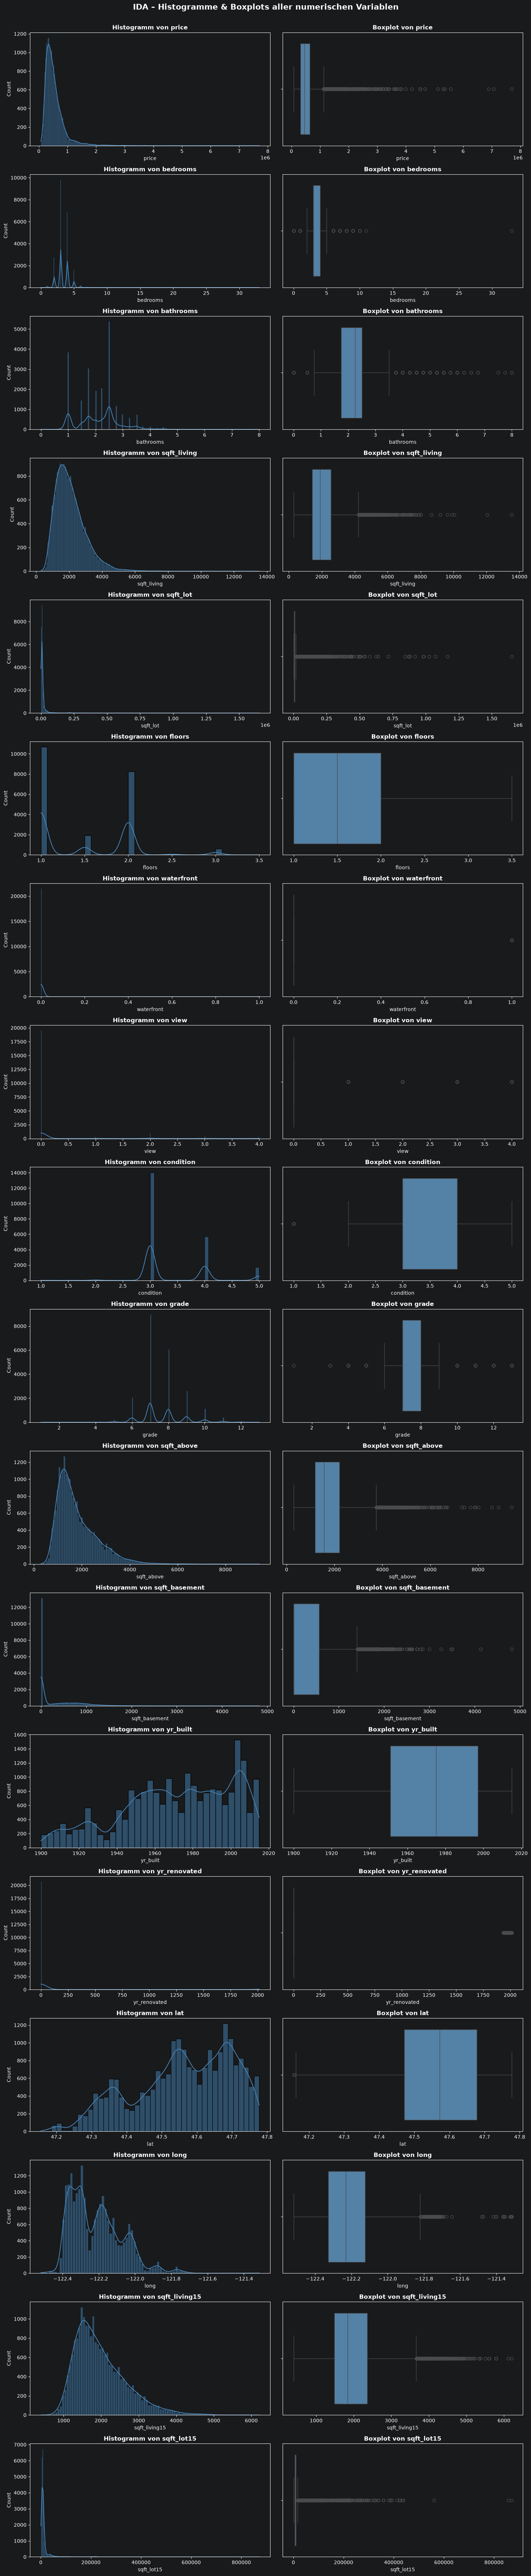

In [46]:
# Histogramme & Boxplots für ALLE numerischen Variablen
num_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
            'floors', 'waterfront', 'view', 'condition', 'grade',
            'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
            'lat', 'long', 'sqft_living15', 'sqft_lot15']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(15, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Histogramm von {col}', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Count')
    
    sns.boxplot(x=df[col], ax=axes[i, 1], color='steelblue')
    axes[i, 1].set_title(f'Boxplot von {col}', fontsize=12, fontweight='bold')

plt.suptitle('IDA – Histogramme & Boxplots aller numerischen Variablen', 
             fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

---
# Exploratory Data Analysis (EDA)

## EDA – Correlation Heatmap


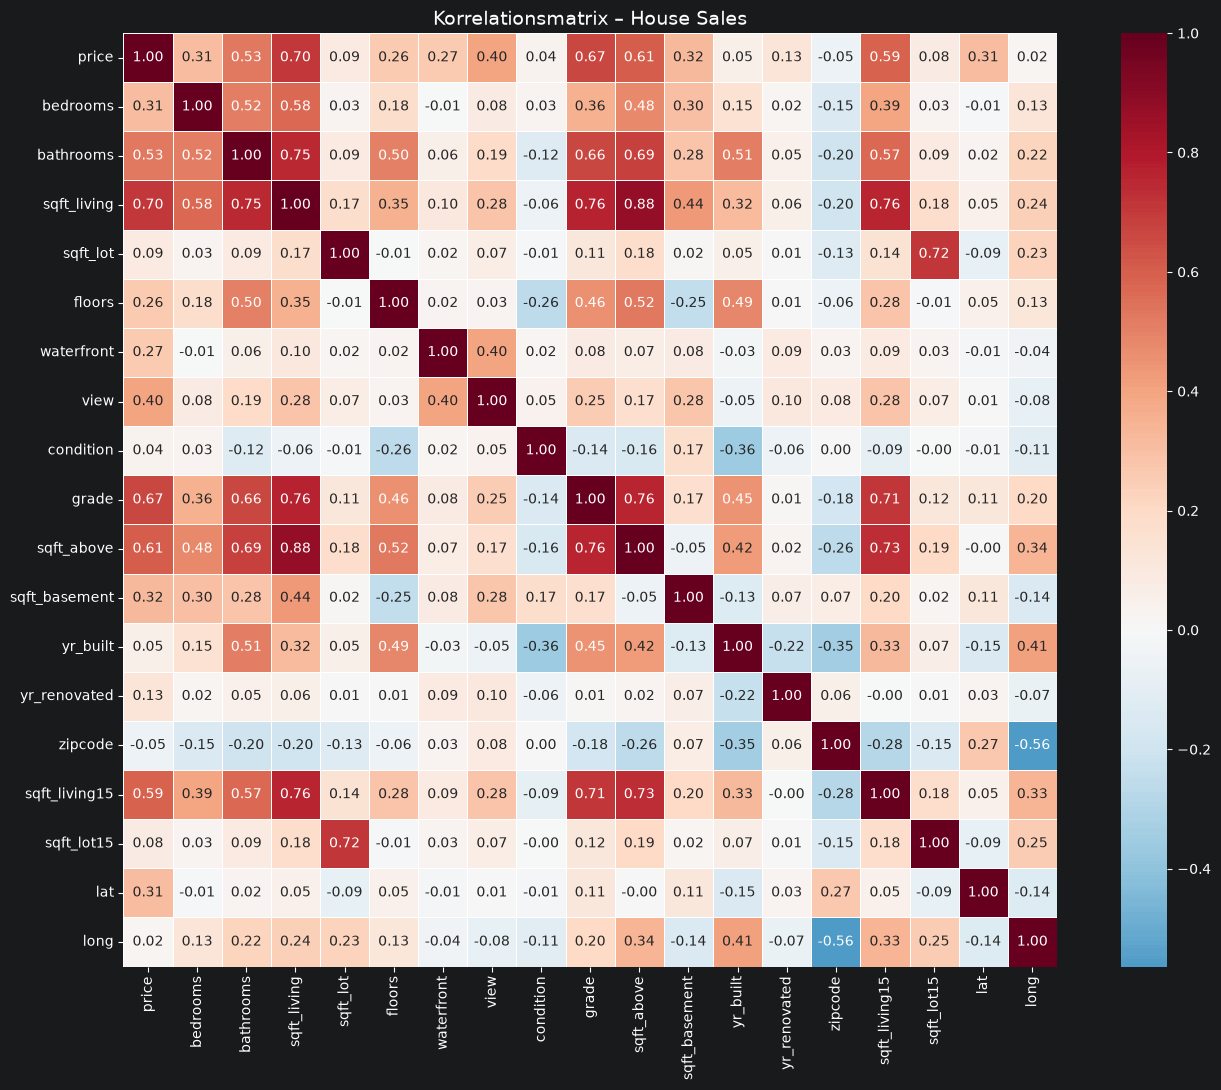

In [47]:
corr_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
             'floors', 'waterfront', 'view', 'condition', 'grade',
             'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
             'zipcode', 'sqft_living15', 'sqft_lot15','lat','long']

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Korrelationsmatrix – House Sales', fontsize=14)
plt.tight_layout()
plt.show()

## EDA – Pairplot
> Erkenne Korrelationen, Verteilungen und natürliche Cluster

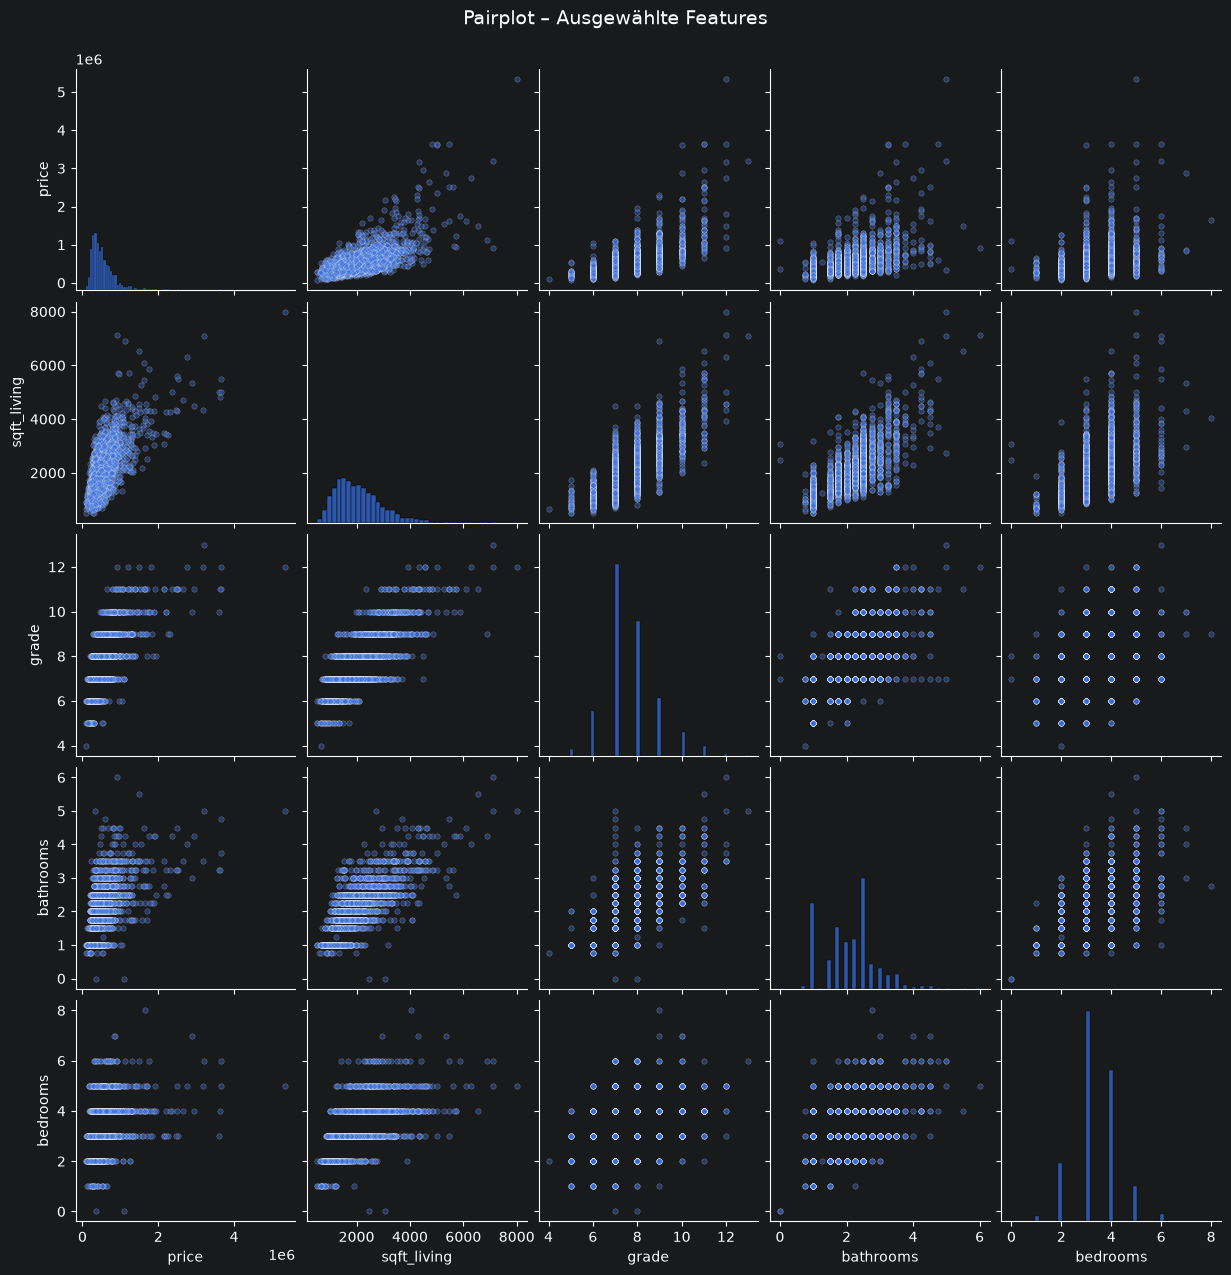

In [48]:
pair_cols = ['price', 'sqft_living', 'grade', 'bathrooms', 'bedrooms']
g = sns.pairplot(df[pair_cols].sample(2000, random_state=42),
                 diag_kind='hist', plot_kws={'alpha': 0.4, 's': 15})
g.fig.suptitle('Pairplot – Ausgewählte Features', y=1.02, fontsize=14)
plt.show()

## EDA – Paretoplot
>

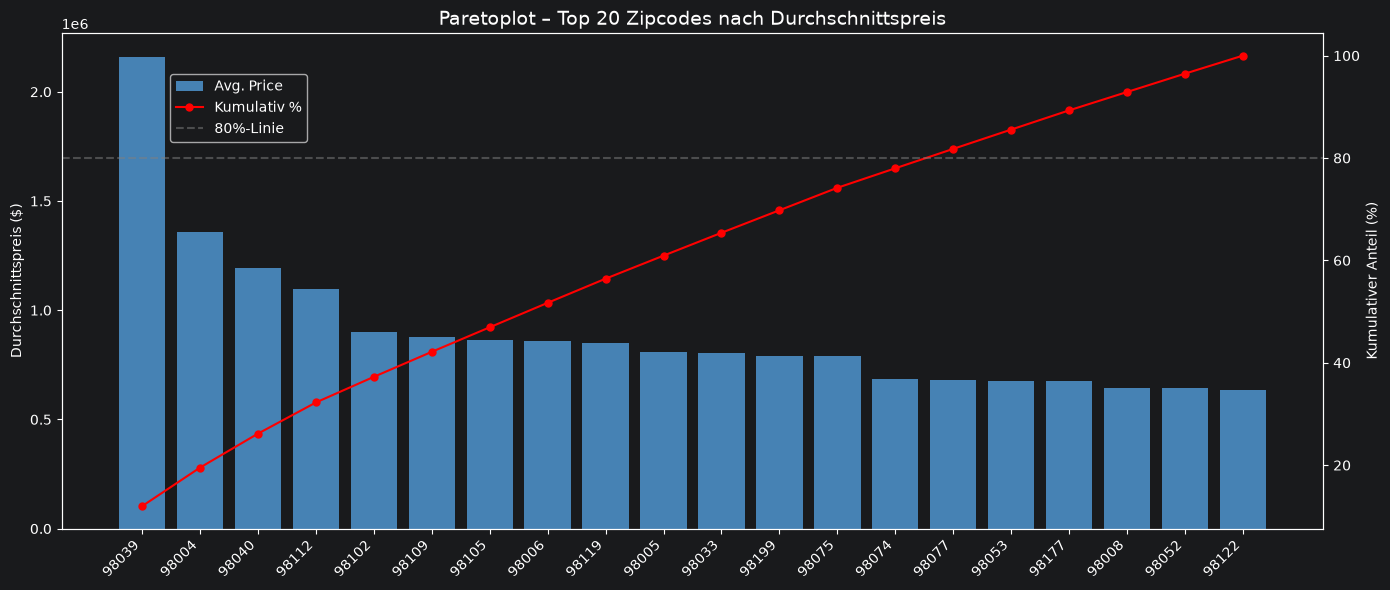

In [49]:
avg_price_zip = df.groupby('zipcode')['price'].mean().sort_values(ascending=False).head(20)
cumulative_pct = avg_price_zip.cumsum() / avg_price_zip.sum() * 100

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(range(len(avg_price_zip)), avg_price_zip.values, color='steelblue', label='Avg. Price')
ax1.set_xticks(range(len(avg_price_zip)))
ax1.set_xticklabels(avg_price_zip.index.astype(str), rotation=45, ha='right')
ax1.set_ylabel('Durchschnittspreis ($)')

ax2 = ax1.twinx()
ax2.plot(range(len(cumulative_pct)), cumulative_pct.values, 'r-o', markersize=5, label='Kumulativ %')
ax2.set_ylabel('Kumulativer Anteil (%)')
ax2.axhline(80, color='gray', linestyle='--', alpha=0.5, label='80%-Linie')

ax1.set_title('Paretoplot – Top 20 Zipcodes nach Durchschnittspreis', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

## EDA – Data Quality Dashboard

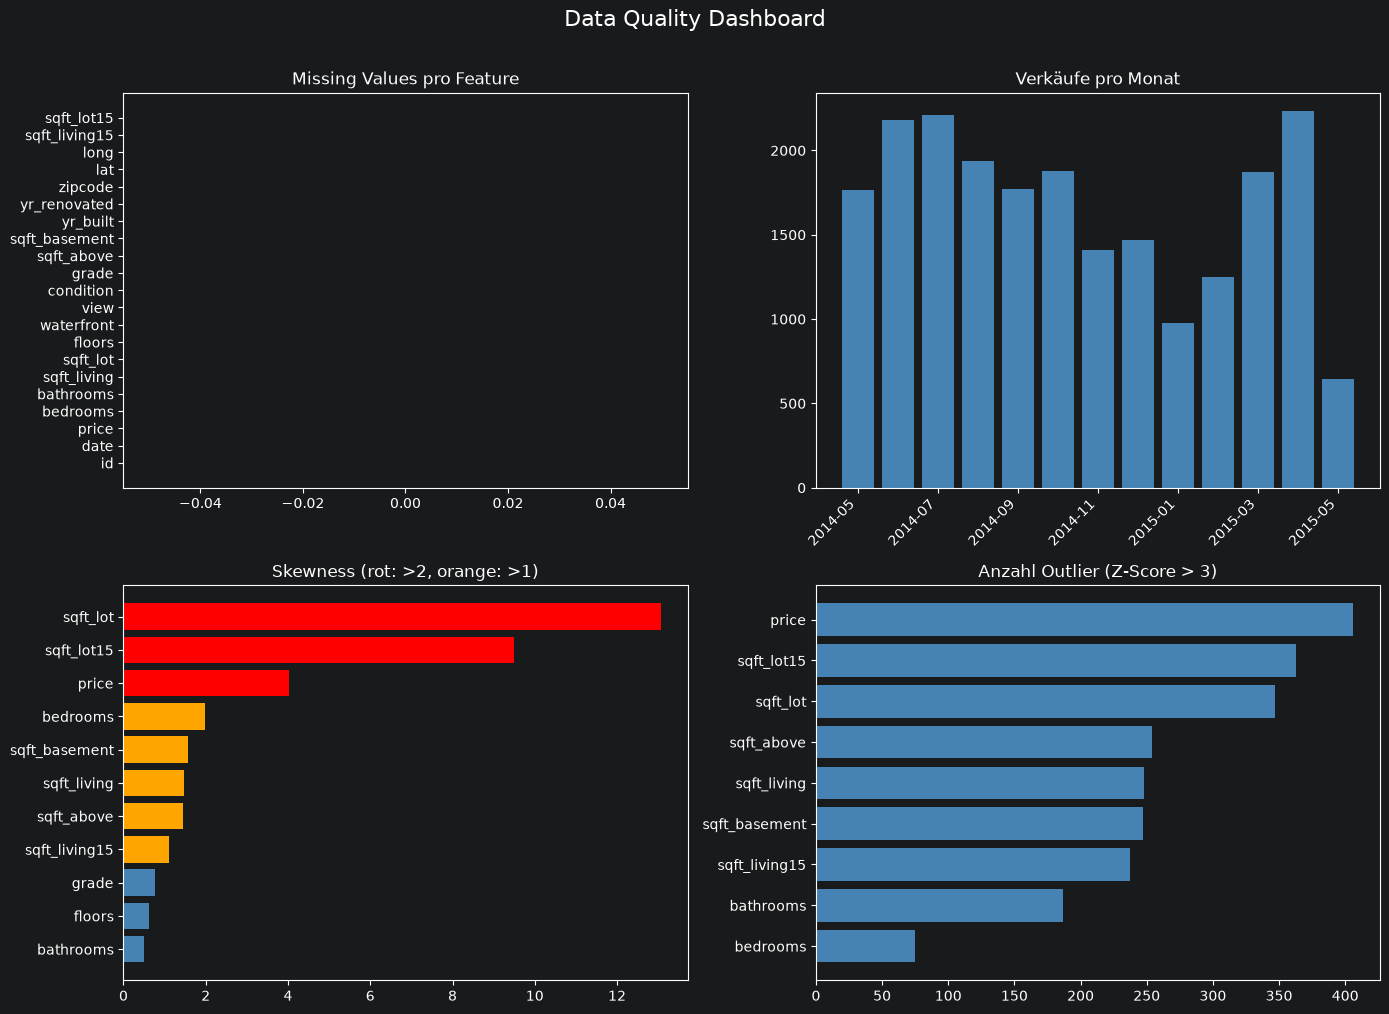

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
axes[0,0].barh(missing.index, missing.values, color='steelblue')
axes[0,0].set_title('Missing Values pro Feature')

# Verkäufe pro Monat
df_temp = df.copy()
df_temp['date'] = pd.to_datetime(df_temp['date'], format='%Y%m%dT%H%M%S')
df_temp['month'] = df_temp['date'].dt.to_period('M')
monthly = df_temp.groupby('month').size()
axes[0,1].bar(range(len(monthly)), monthly.values, color='steelblue')
axes[0,1].set_xticks(range(0, len(monthly), 2))
axes[0,1].set_xticklabels([str(m) for m in monthly.index[::2]], rotation=45, ha='right')
axes[0,1].set_title('Verkäufe pro Monat')

# Skewness
num_cols = ['price','bedrooms','bathrooms','sqft_living','sqft_lot','floors',
            'grade','sqft_above','sqft_basement','sqft_living15','sqft_lot15']
skew_vals = df[num_cols].skew().sort_values()
colors = ['red' if abs(v)>2 else 'orange' if abs(v)>1 else 'steelblue' for v in skew_vals]
axes[1,0].barh(skew_vals.index, skew_vals.values, color=colors)
axes[1,0].axvline(0, color='black', linewidth=0.5)
axes[1,0].set_title('Skewness (rot: >2, orange: >1)')

# Outlier Z-Score
outlier_counts = {}
for col in key_cols:
    z = np.abs(stats.zscore(df[col]))
    outlier_counts[col] = (z > 3).sum()
oc = pd.Series(outlier_counts).sort_values()
axes[1,1].barh(oc.index, oc.values, color='steelblue')
axes[1,1].set_title('Anzahl Outlier (Z-Score > 3)')

plt.suptitle('Data Quality Dashboard', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## What further data should/could be integrated? TODO Hier die Links noch hinzufügen

| Priorität | Datenquelle | Begründung |
|-----------|-------------|------------|
| **Hoch** | Schuldistrikt-Rating | Einer der stärksten Preistreiber in den USA |
| **Hoch** | Grundsteuer (Property Tax) | Direkt preisrelevant |
| **Mittel** | Kriminalitätsrate | Nachbarschaftsqualität |
| **Mittel** | ÖPNV-Anbindung / Pendelzeit | Lage-Bewertung |

## data organized for exploration & modelling

**transformationen:**
1. `id` entfernen (kein prädiktiver Wert)
2. `date` → Jahr, Monat, Quartal extrahieren
3. `yr_renovated` → Binär: `is_renovated` (ja/nein)
4. `zipcode` → Als kategorisch (object) behandeln, sonst entfernen
5. `sqft_basement` → Zusätzlich: `has_basement` (ja/nein)
6. Ausreißer: `bedrooms=33` korrigiert


## stakeholders

**Primäre Nutzer:**
- Steuerbehörden (Grundsteuerbewertung)
- Immobilienmakler (Comparative Market Analysis)

**Sekundäre Nutzer:**
- Investoren (Renditeprognosen)
- Stadtplaner (Entwicklungstrends)
